# Intraday Momentum — "Beat the Market" Replication## Zarattini, Aziz & Barbon (2024), SFI Research Paper N°24-97**Paper results (2007-2024, final version with VWAP stop + dynamic sizing):**- Total Return: 1,985%, CAGR: 19.6%, Sharpe: 1.33, MDD: -25%- Alpha: 19.6%, Beta: -0.07, Hit Ratio: 43%**Strategy logic:**1. Compute time-varying "Noise Area" boundaries at each 30-min checkpoint2. If price breaks above upper boundary → long; below lower → short3. Trailing stop = max(current_band, VWAP) for longs, min for shorts4. All positions closed at 16:00 (no overnight)5. Dynamic sizing: target 2% daily vol using 14-day realized vol of SPY**Data:** 30-min bars from Alpaca (SPY), resampled from 5-min

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import time as dt_time
from alpaca.data.timeframe import TimeFrame, TimeFrameUnit

from _shared.loaders_data import fetch_historical_data
from _shared.fees import calculate_fees
from _shared.metrics import evaluate_strategy, print_metrics
from _shared.plotting import plot_equity_curve, plot_trade_returns, plot_yearly_returns
from _shared.significance import full_significance_report, print_significance_report
from _shared.results import save_trades

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
# =============================================================================
# CONFIGURATION
# =============================================================================

SYMBOL = "SPY"
START_DATE = "2016-01-01"
END_DATE = "2026-04-01"
STARTING_CAPITAL = 100_000
STRATEGY_NAME = "Intraday Momentum"
SAVE_NAME = "intraday_momentum"

# Paper parameters
LOOKBACK = 14              # days for noise boundary calculation
VOL_MULTIPLIER = 1.0       # noise area width multiplier (paper uses 1.0)
SIGMA_TARGET = 0.02        # 2% daily vol target for dynamic sizing
MAX_LEVERAGE = 4.0         # cap leverage at 4x
COMMISSION_PER_SHARE = 0.0035   # IBKR entry-level
SLIPPAGE_PER_SHARE = 0.001      # from paper's real-market study

# Checkpoint times (HH:00 and HH:30 from 10:00 to 15:30)
CHECKPOINTS = []
for h in range(10, 16):
    CHECKPOINTS.append(dt_time(h, 0))
    if h < 16:
        CHECKPOINTS.append(dt_time(h, 30))
# Remove 16:00 if present, last checkpoint is 15:30
CHECKPOINTS = [t for t in CHECKPOINTS if t < dt_time(16, 0)]
print(f"Checkpoints: {[str(t)[:5] for t in CHECKPOINTS]}")

Checkpoints: ['10:00', '10:30', '11:00', '11:30', '12:00', '12:30', '13:00', '13:30', '14:00', '14:30', '15:00', '15:30']


In [3]:
# =============================================================================
# DATA FETCHING — 5-min bars, then resample to 30-min
# =============================================================================

data_dict = fetch_historical_data([SYMBOL], TimeFrame(5, TimeFrameUnit.Minute), START_DATE, END_DATE)

raw = data_dict[SYMBOL].copy()
if raw.index.tz is None:
    raw.index = raw.index.tz_localize("UTC").tz_convert("US/Eastern")
else:
    raw.index = raw.index.tz_convert("US/Eastern")
raw = raw.reset_index()

# Filter to RTH only (9:30 - 16:00)
raw["time"] = raw["timestamp"].dt.time
raw["date"] = raw["timestamp"].dt.date
raw = raw[(raw["time"] >= dt_time(9, 30)) & (raw["time"] < dt_time(16, 0))].copy()
print(f"5-min RTH bars: {len(raw):,}")

# Compute cumulative VWAP per day from 5-min bars
# VWAP = cumsum(price * volume) / cumsum(volume)
raw["typical_price"] = (raw["high"] + raw["low"] + raw["close"]) / 3
raw["tp_vol"] = raw["typical_price"] * raw["volume"]

daily_groups = raw.groupby("date")
raw["cum_tp_vol"] = daily_groups["tp_vol"].cumsum()
raw["cum_vol"] = daily_groups["volume"].cumsum()
raw["vwap_calc"] = raw["cum_tp_vol"] / raw["cum_vol"]

print(f"VWAP computed for {raw['date'].nunique()} days")

Fetching SPY...
  472,076 bars
5-min RTH bars: 200,793
VWAP computed for 2575 days


In [4]:
# =============================================================================
# BUILD 30-MIN CHECKPOINT BARS WITH VWAP
# =============================================================================
# For each day, create bars at each checkpoint time.
# Each bar represents the state AT that checkpoint.

checkpoint_rows = []

for date, day_df in raw.groupby("date"):
    day_df = day_df.sort_values("timestamp")
    if len(day_df) < 20:  # skip short days
        continue
    
    day_open = day_df["open"].iloc[0]
    prev_close_mask = day_df["timestamp"].dt.time == dt_time(9, 30)
    
    for cp_time in CHECKPOINTS:
        # Get all 5-min bars up to and including this checkpoint
        mask = day_df["time"] <= cp_time
        bars_up_to = day_df[mask]
        
        if len(bars_up_to) == 0:
            continue
        
        # Current price at checkpoint = close of last bar at or before checkpoint
        # Find bars at exactly this checkpoint time
        exact_mask = day_df["time"] == cp_time
        if exact_mask.any():
            cp_close = day_df[exact_mask]["close"].iloc[-1]
        else:
            cp_close = bars_up_to["close"].iloc[-1]
        
        cp_high = bars_up_to["high"].max()
        cp_low = bars_up_to["low"].min()
        cp_vwap = bars_up_to["vwap_calc"].iloc[-1]
        
        # Move from open as percentage
        move_from_open = abs(cp_close / day_open - 1)
        
        checkpoint_rows.append({
            "date": pd.Timestamp(date),
            "checkpoint": cp_time,
            "open": day_open,
            "close": cp_close,
            "high_so_far": cp_high,
            "low_so_far": cp_low,
            "vwap": cp_vwap,
            "move_from_open": move_from_open,
        })

checkpoints_df = pd.DataFrame(checkpoint_rows)
print(f"Checkpoint observations: {len(checkpoints_df):,}")
print(f"Days with checkpoints: {checkpoints_df['date'].nunique():,}")
print(f"Avg checkpoints per day: {len(checkpoints_df) / checkpoints_df['date'].nunique():.1f}")

Checkpoint observations: 30,900
Days with checkpoints: 2,575
Avg checkpoints per day: 12.0


In [6]:
# =============================================================================
# COMPUTE NOISE AREA BOUNDARIES (time-of-day dependent)
# =============================================================================
# For each day t and checkpoint time HH:MM:
#   sigma(t, HH:MM) = avg of |close/open - 1| at HH:MM over last 14 days
#   Upper = max(open_t, prev_close) * (1 + VM * sigma)
#   Lower = min(open_t, prev_close) * (1 - VM * sigma)

# Get previous day's close for gap adjustment
day_last_close = checkpoints_df.groupby("date")["close"].last()
prev_close_map = day_last_close.shift(1)
checkpoints_df["prev_close"] = checkpoints_df["date"].map(prev_close_map)

noise_bounds = []

unique_dates = np.sort(checkpoints_df["date"].unique())

# Build a pivot: rows = dates, columns = checkpoint times, values = move_from_open
pivot = checkpoints_df.pivot_table(index="date", columns="checkpoint", 
                                    values="move_from_open", aggfunc="first")

# Rolling 14-day mean for each checkpoint time (shift by 1 to avoid look-ahead)
sigma_pivot = pivot.shift(1).rolling(LOOKBACK, min_periods=LOOKBACK).mean()

# Melt back to long format
sigma_long = sigma_pivot.reset_index().melt(id_vars="date", var_name="checkpoint", 
                                             value_name="sigma")

# Merge sigma into checkpoints
checkpoints_df = checkpoints_df.merge(sigma_long, on=["date", "checkpoint"], how="left")

# Compute boundaries with gap adjustment
checkpoints_df["ref_upper"] = checkpoints_df[["open", "prev_close"]].max(axis=1)
checkpoints_df["ref_lower"] = checkpoints_df[["open", "prev_close"]].min(axis=1)

checkpoints_df["upper_bound"] = checkpoints_df["ref_upper"] * (1 + VOL_MULTIPLIER * checkpoints_df["sigma"])
checkpoints_df["lower_bound"] = checkpoints_df["ref_lower"] * (1 - VOL_MULTIPLIER * checkpoints_df["sigma"])

# Drop rows without sigma (warmup period)
valid = checkpoints_df.dropna(subset=["sigma"]).copy()
print(f"Valid checkpoints (after warmup): {len(valid):,}")
print(f"Valid trading days: {valid['date'].nunique():,}")

# Sample
sample_day = valid["date"].unique()[100]
sample = valid[valid["date"] == sample_day][["checkpoint", "open", "close", "sigma", 
                                              "upper_bound", "lower_bound", "vwap"]]
print(f"\nSample day ({sample_day.date()}):")
print(sample.to_string(index=False))

Valid checkpoints (after warmup): 30,732
Valid trading days: 2,561

Sample day (2016-06-16):
checkpoint  open  close    sigma  upper_bound  lower_bound       vwap
  10:00:00 176.3 175.52 0.001576   178.210359   176.022210 175.895526
  10:30:00 176.3 175.47 0.001707   178.233706   175.999076 175.777382
  11:00:00 176.3 175.88 0.001909   178.269733   175.963380 175.739468
  11:30:00 176.3 176.25 0.001707   178.233803   175.998981 175.806801
  12:00:00 176.3 176.01 0.001724   178.236663   175.996146 175.836545
  12:30:00 176.3 176.58 0.001570   178.209303   176.023256 175.932027
  13:00:00 176.3 177.00 0.001858   178.260571   175.972457 176.061396
  13:30:00 176.3 176.71 0.001901   178.268228   175.964870 176.152611
  14:00:00 176.3 176.87 0.002417   178.360084   175.873856 176.199169
  14:30:00 176.3 177.07 0.002494   178.373737   175.860328 176.266880
  15:00:00 176.3 177.31 0.002866   178.439939   175.794732 176.349619
  15:30:00 176.3 177.76 0.002447   178.365313   175.868675 176.4673

In [7]:
# =============================================================================
# COMPUTE DYNAMIC SIZING (volatility targeting)
# =============================================================================
# sigma_SPY = 14-day rolling std of daily returns
# shares = AUM * min(4, sigma_target / sigma_SPY) / open_price

# Get daily OHLC for vol calculation
daily_prices = checkpoints_df.groupby("date").agg(
    day_open=("open", "first"),
    day_close=("close", "last"),
).reset_index()

daily_prices["daily_ret"] = daily_prices["day_close"].pct_change()
daily_prices["realized_vol"] = daily_prices["daily_ret"].rolling(LOOKBACK).std()

# Leverage multiplier (shift to avoid look-ahead)
daily_prices["leverage"] = (SIGMA_TARGET / daily_prices["realized_vol"]).clip(upper=MAX_LEVERAGE)
daily_prices["leverage"] = daily_prices["leverage"].shift(1)  # use yesterday's vol

daily_prices = daily_prices.dropna(subset=["leverage"])
print(f"Days with valid leverage: {len(daily_prices):,}")
print(f"Avg leverage: {daily_prices['leverage'].mean():.2f}x")
print(f"Median leverage: {daily_prices['leverage'].median():.2f}x")
print(f"Max leverage: {daily_prices['leverage'].max():.2f}x (capped at {MAX_LEVERAGE}x)")

Days with valid leverage: 2,560
Avg leverage: 2.69x
Median leverage: 2.69x
Max leverage: 4.00x (capped at 4.0x)


In [8]:
# =============================================================================
# PREPARE 5-MIN BAR RETURNS FOR FAST ALPHA OVERLAY
# =============================================================================
# The fast alpha signal: after a breakout is detected on 30-min checkpoints,
# delay entry until a 5-min bar moves in the OPPOSITE direction (micro-pullback).
# Same for exits: delay exit until a 5-min bar moves in the favorable direction.
# This improves entry/exit prices without adding turnover.
#
# Reference: Zarattini & Pagani (2026), "Improving Performance with Fast Alphas"

# Build a lookup: for each day, store the 5-min bar returns indexed by time
# We need: given a checkpoint time, find the next 5-min bar in the opposite direction

five_min_returns = {}

for date, day_df in raw.groupby("date"):
    day_df = day_df.sort_values("timestamp")
    if len(day_df) < 20:
        continue
    
    # Compute 5-min returns
    bars = day_df[["timestamp", "time", "close"]].copy()
    bars["ret"] = bars["close"].pct_change()
    bars = bars.dropna()
    
    five_min_returns[pd.Timestamp(date)] = bars[["time", "close", "ret"]].reset_index(drop=True)

print(f"Days with 5-min returns: {len(five_min_returns):,}")

def find_pullback_price(day_bars, after_time, direction, max_wait_bars=6):
    """
    Find the close price of the first 5-min bar that moves opposite to direction.
    
    Parameters
    ----------
    day_bars : DataFrame with columns [time, close, ret]
    after_time : time object — look for pullback after this checkpoint
    direction : 'long' or 'short' — the position we want to enter/exit
    max_wait_bars : int — max 5-min bars to wait (default 6 = 30 min)
    
    Returns
    -------
    (pullback_price, pullback_time) or (None, None) if no pullback found
    """
    future = day_bars[day_bars["time"] > after_time]
    
    if len(future) == 0:
        return None, None
    
    for idx in range(min(max_wait_bars, len(future))):
        bar = future.iloc[idx]
        
        if direction == "long" and bar["ret"] < 0:
            # For long entry: want a down bar (buy the dip)
            return bar["close"], bar["time"]
        elif direction == "short" and bar["ret"] > 0:
            # For short entry: want an up bar (sell the rip)
            return bar["close"], bar["time"]
    
    return None, None

def find_exit_pullback_price(day_bars, after_time, position, max_wait_bars=6):
    """
    Find improved exit price by waiting for a counter-move.
    
    For long exit (being stopped out): wait for an UP bar before selling.
    For short exit (being stopped out): wait for a DOWN bar before covering.
    """
    future = day_bars[day_bars["time"] > after_time]
    
    if len(future) == 0:
        return None, None
    
    for idx in range(min(max_wait_bars, len(future))):
        bar = future.iloc[idx]
        
        if position == "long" and bar["ret"] > 0:
            # Exiting long: wait for an up bar to sell higher
            return bar["close"], bar["time"]
        elif position == "short" and bar["ret"] < 0:
            # Exiting short: wait for a down bar to cover lower
            return bar["close"], bar["time"]
    
    return None, None

print("Fast alpha helper functions loaded.")

Days with 5-min returns: 2,575
Fast alpha helper functions loaded.


In [11]:
# =============================================================================
# INTRADAY BACKTEST ENGINE — BASELINE + FAST ALPHA OVERLAY
# =============================================================================
# Runs both versions in a single pass:
#   1. Baseline: enter/exit immediately at checkpoint prices
#   2. Fast Alpha: delay entry until 5-min pullback, delay exit until counter-move

# Merge leverage info into valid checkpoints
valid_with_lev = valid.merge(
    daily_prices[["date", "leverage", "day_open"]], on="date", how="inner"
)
print(f"Checkpoints with leverage: {len(valid_with_lev):,}")

def run_intraday_backtest(valid_with_lev, five_min_returns, starting_capital,
                          cost_per_share, use_fast_alpha=False, max_wait_bars=6):
    """
    Run the intraday momentum backtest.
    
    Parameters
    ----------
    use_fast_alpha : bool — if True, apply fast alpha overlay for entries/exits
    max_wait_bars : int — max 5-min bars to wait for pullback (6 = 30 min)
    """
    equity = starting_capital
    trades = []
    daily_pnl = []
    
    trading_days = sorted(valid_with_lev["date"].unique())
    
    for day in trading_days:
        day_data = valid_with_lev[valid_with_lev["date"] == day].sort_values("checkpoint")
        
        if len(day_data) < 3:
            daily_pnl.append({"date": day, "pnl": 0, "equity": equity, "trades": 0})
            continue
        
        leverage = day_data["leverage"].iloc[0]
        day_open_price = day_data["day_open"].iloc[0]
        notional = equity * leverage
        max_shares = int(notional / day_open_price)
        
        if max_shares <= 0:
            daily_pnl.append({"date": day, "pnl": 0, "equity": equity, "trades": 0})
            continue
        
        # Get 5-min bars for this day (for fast alpha)
        day_5min = five_min_returns.get(day, None)
        
        position = None
        entry_price = None
        entry_time = None
        day_trades = []
        shares = max_shares
        
        for _, cp in day_data.iterrows():
            cp_price = cp["close"]
            cp_time = cp["checkpoint"]
            upper = cp["upper_bound"]
            lower = cp["lower_bound"]
            vwap = cp["vwap"]
            
            if position is None:
                # ── Check for entry ──
                signal = None
                if cp_price > upper:
                    signal = "long"
                elif cp_price < lower:
                    signal = "short"
                
                if signal is not None:
                    actual_entry_price = cp_price
                    actual_entry_time = cp_time
                    
                    # Fast alpha: wait for pullback
                    if use_fast_alpha and day_5min is not None:
                        pb_price, pb_time = find_pullback_price(
                            day_5min, cp_time, signal, max_wait_bars
                        )
                        if pb_price is not None:
                            actual_entry_price = pb_price
                            actual_entry_time = pb_time
                        # If no pullback found within window, enter at original price
                    
                    position = signal
                    entry_price = actual_entry_price
                    entry_time = actual_entry_time
            
            else:
                # ── Check trailing stop ──
                should_close = False
                
                if position == "long":
                    trail_stop = max(upper, vwap)
                    if cp_price < trail_stop:
                        should_close = True
                elif position == "short":
                    trail_stop = min(lower, vwap)
                    if cp_price > trail_stop:
                        should_close = True
                
                if should_close:
                    actual_exit_price = cp_price
                    actual_exit_time = cp_time
                    
                    # Fast alpha: wait for counter-move before exiting
                    if use_fast_alpha and day_5min is not None:
                        ex_price, ex_time = find_exit_pullback_price(
                            day_5min, cp_time, position, max_wait_bars
                        )
                        if ex_price is not None:
                            actual_exit_price = ex_price
                            actual_exit_time = ex_time
                    
                    if position == "long":
                        gross = shares * (actual_exit_price - entry_price)
                    else:
                        gross = shares * (entry_price - actual_exit_price)
                    
                    cost = shares * cost_per_share * 2
                    net = gross - cost
                    
                    day_trades.append({
                        "entry_time": pd.Timestamp.combine(day, entry_time),
                        "exit_time": pd.Timestamp.combine(day, actual_exit_time),
                        "position": position,
                        "entry_price": round(entry_price, 4),
                        "exit_price": round(actual_exit_price, 4),
                        "exit_reason": "trail_stop",
                        "shares": shares,
                        "gross_pnl": round(gross, 2),
                        "fees": round(cost, 2),
                        "net_pnl": round(net, 2),
                    })
                    
                    # Check for reversal
                    if position == "long" and cp_price < lower:
                        rev_entry = cp_price
                        rev_time = cp_time
                        if use_fast_alpha and day_5min is not None:
                            pb_p, pb_t = find_pullback_price(day_5min, cp_time, "short", max_wait_bars)
                            if pb_p is not None:
                                rev_entry = pb_p
                                rev_time = pb_t
                        position = "short"
                        entry_price = rev_entry
                        entry_time = rev_time
                    elif position == "short" and cp_price > upper:
                        rev_entry = cp_price
                        rev_time = cp_time
                        if use_fast_alpha and day_5min is not None:
                            pb_p, pb_t = find_pullback_price(day_5min, cp_time, "long", max_wait_bars)
                            if pb_p is not None:
                                rev_entry = pb_p
                                rev_time = pb_t
                        position = "long"
                        entry_price = rev_entry
                        entry_time = rev_time
                    else:
                        position = None
                        entry_price = None
        
        # ── Close at EOD ──
        if position is not None:
            eod_price = day_data["close"].iloc[-1]
            # No fast alpha on EOD — must close
            if position == "long":
                gross = shares * (eod_price - entry_price)
            else:
                gross = shares * (entry_price - eod_price)
            cost = shares * cost_per_share * 2
            net = gross - cost
            
            day_trades.append({
                "entry_time": pd.Timestamp.combine(day, entry_time),
                "exit_time": pd.Timestamp.combine(day, dt_time(16, 0)),
                "position": position,
                "entry_price": round(entry_price, 4),
                "exit_price": round(eod_price, 4),
                "exit_reason": "eod_close",
                "shares": shares,
                "gross_pnl": round(gross, 2),
                "fees": round(cost, 2),
                "net_pnl": round(net, 2),
            })
        
        # Update equity
        day_net = sum(t["net_pnl"] for t in day_trades)
        eq_before = equity
        equity += day_net
        
        running_eq = eq_before
        for t in day_trades:
            t["equity_before"] = round(running_eq, 2)
            running_eq += t["net_pnl"]
            t["equity"] = round(running_eq, 2)
            t["risk"] = round(abs(t["entry_price"] - t["exit_price"]), 4)
            trades.append(t)
        
        daily_pnl.append({
            "date": day, "pnl": round(day_net, 2),
            "equity": round(equity, 2), "trades": len(day_trades),
        })
    
    results_df = pd.DataFrame(trades)
    daily_df = pd.DataFrame(daily_pnl)
    
    if not results_df.empty:
        results_df["entry_time"] = pd.to_datetime(results_df["entry_time"])
        results_df["exit_time"] = pd.to_datetime(results_df["exit_time"])
    
    return results_df, daily_df, equity

# ── Run both versions ──
cost_per_share = COMMISSION_PER_SHARE + SLIPPAGE_PER_SHARE

print("Running BASELINE (no fast alpha)...")
results_base, daily_base, eq_base = run_intraday_backtest(
    valid_with_lev, five_min_returns, STARTING_CAPITAL, cost_per_share,
    use_fast_alpha=False
)
print(f"  Trades: {len(results_base):,}, Final equity: ${eq_base:,.2f}")

print("\nRunning FAST ALPHA overlay...")
results_fa, daily_fa, eq_fa = run_intraday_backtest(
    valid_with_lev, five_min_returns, STARTING_CAPITAL, cost_per_share,
    use_fast_alpha=True, max_wait_bars=6
)
print(f"  Trades: {len(results_fa):,}, Final equity: ${eq_fa:,.2f}")

# Use fast alpha version as the primary results
results = results_fa
daily_df = daily_fa

Checkpoints with leverage: 30,720
Running BASELINE (no fast alpha)...
  Trades: 2,303, Final equity: $266,322.91

Running FAST ALPHA overlay...
  Trades: 2,303, Final equity: $690,271.46


Metric                      Baseline      Fast Alpha        Delta
  Total Return               166.32%         590.27%     +423.95%
  Annualized                    6.87           13.99        +7.12
  Max Drawdown               -21.38%         -17.32%       +4.06%
  Sharpe                        0.79            1.52        +0.73
  Sortino                       1.73            3.23         +1.5
  Profit Factor                 1.18            1.36 +0.18000000000000016
  Trades                        2303            2303           +0
  Win Rate                    37.47%          46.20%       +8.73%
  Avg Win            $     1,285.25 $     2,109.43 $   +824.18
  Avg Loss           $      -654.75 $    -1,335.08 $   -680.33
  Total Fees         $    23,592.59 $    40,128.09 $+16,535.50
  Final Equity       $   266,322.91 $   690,271.46 $+423,948.55


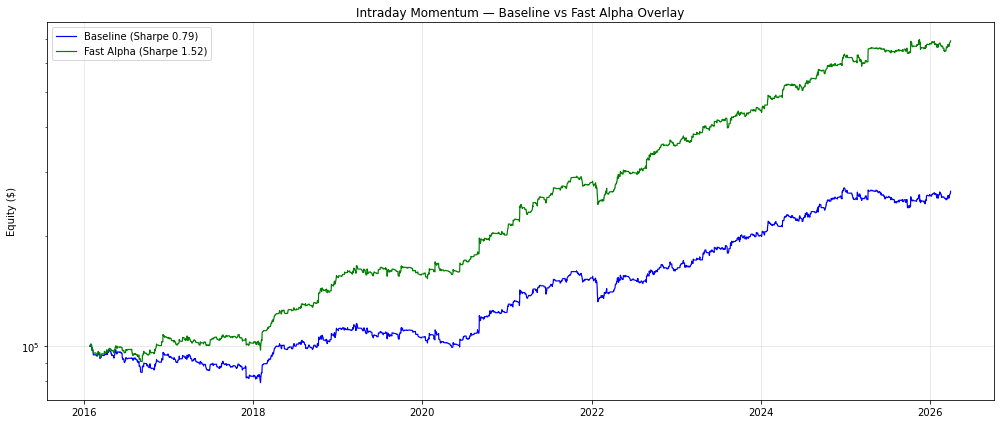


YEARLY RETURNS COMPARISON
Year     Baseline   Fast Alpha    Delta
----------------------------------------
  2016      -5.44%        5.62%  +11.06%
  2017     -12.66%       -3.56%   +9.10%
  2018      34.39%       52.11%  +17.72%
  2019      -4.67%        1.81%   +6.48%
  2020      16.84%       28.01%  +11.17%
  2021      24.44%       39.48%  +15.04%
  2022       5.54%       26.47%  +20.93%
  2023      24.07%       24.79%   +0.72%
  2024      32.89%       41.00%   +8.11%
  2025      -2.54%        8.33%  +10.87%
  2026       2.08%        1.67%   -0.41%


In [12]:
# =============================================================================
# BASELINE vs FAST ALPHA COMPARISON
# =============================================================================

metrics_base = evaluate_strategy(results_base, "Baseline")
metrics_fa = evaluate_strategy(results_fa, "Fast Alpha Overlay")

# Side-by-side comparison
compare_keys = ["Total Return", "Annualized", "Max Drawdown", "Sharpe", "Sortino",
                "Profit Factor", "Trades", "Win Rate", "Avg Win", "Avg Loss",
                "Total Fees", "Final Equity"]

print(f"{'Metric':<20} {'Baseline':>15} {'Fast Alpha':>15} {'Delta':>12}")
print("=" * 65)
for k in compare_keys:
    v1 = metrics_base.get(k, 0)
    v2 = metrics_fa.get(k, 0)
    if isinstance(v1, (int, float)) and isinstance(v2, (int, float)):
        delta = v2 - v1
        if "Return" in k or "Drawdown" in k or "Rate" in k:
            print(f"  {k:<18} {v1:>14.2f}% {v2:>14.2f}% {delta:>+11.2f}%")
        elif "Equity" in k or "Win" in k or "Loss" in k or "Fees" in k:
            print(f"  {k:<18} ${v1:>13,.2f} ${v2:>13,.2f} ${delta:>+10,.2f}")
        else:
            print(f"  {k:<18} {v1:>15} {v2:>15} {delta:>+12}")
    else:
        print(f"  {k:<18} {v1:>15} {v2:>15}")

# Equity curves comparison
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(pd.to_datetime(daily_base["date"]).values, daily_base["equity"].values,
        label=f"Baseline (Sharpe {metrics_base['Sharpe']:.2f})", color="blue", linewidth=1.2)
ax.plot(pd.to_datetime(daily_fa["date"]).values, daily_fa["equity"].values,
        label=f"Fast Alpha (Sharpe {metrics_fa['Sharpe']:.2f})", color="green", linewidth=1.2)
ax.set_yscale("log")
ax.set_ylabel("Equity ($)")
ax.set_title("Intraday Momentum — Baseline vs Fast Alpha Overlay")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Yearly comparison
print("\nYEARLY RETURNS COMPARISON")
print(f"{'Year':<6} {'Baseline':>10} {'Fast Alpha':>12} {'Delta':>8}")
print("-" * 40)
yr_base = metrics_base.get("Yearly Returns", {})
yr_fa = metrics_fa.get("Yearly Returns", {})
for year in sorted(set(list(yr_base.keys()) + list(yr_fa.keys()))):
    b = yr_base.get(year, 0)
    f = yr_fa.get(year, 0)
    print(f"  {year}  {b:>9.2f}% {f:>11.2f}% {f-b:>+7.2f}%")

  Strategy             Intraday Momentum
  Total Return             590.27%
  Annualized                13.99
  Max Drawdown             -17.32%
  Sharpe                     1.52
  Sortino                    3.23
  Profit Factor              1.36
  Trades               2303
  Win Rate                  46.20%
  Avg Win              $    2,109.43
  Avg Loss             $   -1,335.08
  Long Trades          1181
  Long PnL             $  357,771.11
  Long WR                   50.13%
  Short Trades         1122
  Short PnL            $  232,500.35
  Short WR                  42.07%
  Total Fees           $   40,128.09
  Final Equity         $  690,271.46

Yearly Returns:
  2016: 5.62%
  2017: -3.56%
  2018: 52.11%
  2019: 1.81%
  2020: 28.01%
  2021: 39.48%
  2022: 26.47%
  2023: 24.79%
  2024: 41.0%
  2025: 8.33%
  2026: 1.67%


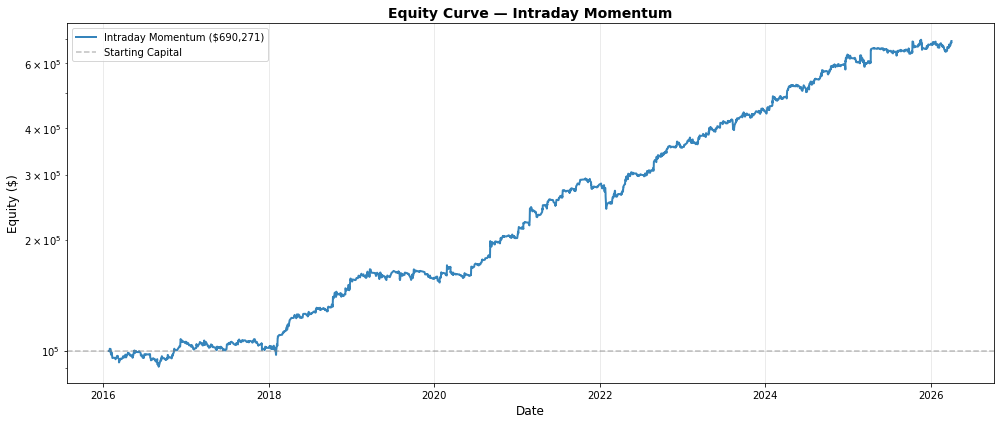

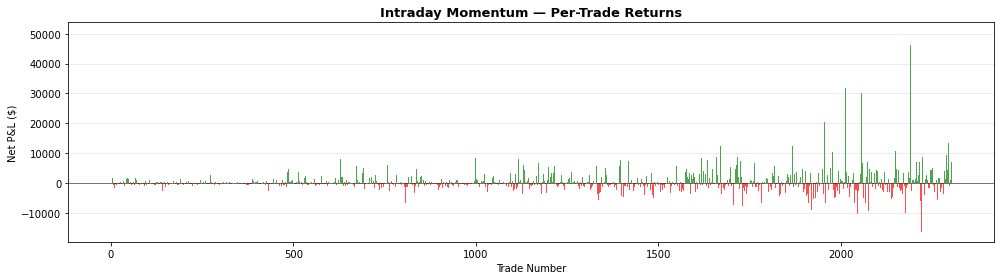


--- Paper Reference (2007-2024, with VWAP stop + dynamic sizing) ---
  Total Return:  1,985%
  CAGR:          19.6%
  Vol:           14.3%
  Sharpe:        1.33
  Hit Ratio:     43%
  MDD:           -25%
  Alpha:         19.6%
  Beta:          -0.07


In [13]:
# =============================================================================
# RESULTS & METRICS
# =============================================================================

if not results.empty:
    metrics = evaluate_strategy(results, STRATEGY_NAME)
    print_metrics(metrics)
    
    plot_equity_curve(results, label=STRATEGY_NAME, starting_capital=STARTING_CAPITAL)
    plot_trade_returns(results, title=f"{STRATEGY_NAME} — Per-Trade Returns")
    
    # Paper reference values (Table 3, final version):
    print("\n--- Paper Reference (2007-2024, with VWAP stop + dynamic sizing) ---")
    print("  Total Return:  1,985%")
    print("  CAGR:          19.6%")
    print("  Vol:           14.3%")
    print("  Sharpe:        1.33")
    print("  Hit Ratio:     43%")
    print("  MDD:           -25%")
    print("  Alpha:         19.6%")
    print("  Beta:          -0.07")

In [14]:
# =============================================================================
# SIGNIFICANCE TESTING
# =============================================================================

if not results.empty and len(results) >= 5:
    report = full_significance_report(results, strategy_name=STRATEGY_NAME)
    print_significance_report(report)


STATISTICAL SIGNIFICANCE — Intraday Momentum

1. t-test (returns > 0)
   Mean return:  0.0881% per trade
   t-statistic:  4.5855
   p-value:      2e-06
   Significant:  YES

2. Bootstrap Sharpe (95% CI)
   Observed Sharpe:   1.5172
   95% CI:            [0.9167, 2.0924]
   % below zero:      0.0%
   Significant:       YES

3. Permutation test (random signs)
   Observed Sharpe:   1.5172
   p-value:           0.0
   Significant:       YES

──────────────────────────────────────────────────────────────────────
VERDICT: SIGNIFICANT (strong) (3/3 tests pass)


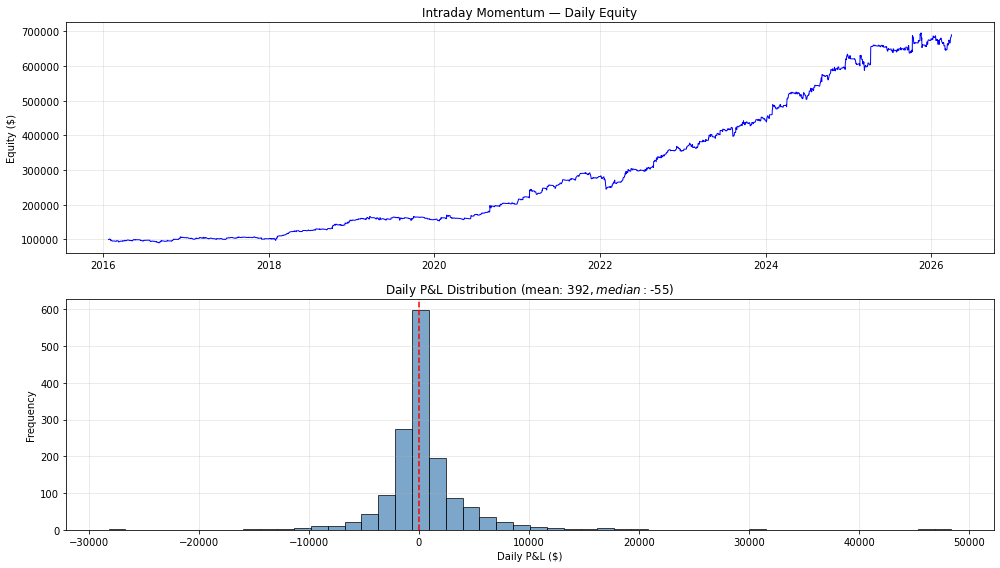

Active trading days: 1504 / 2560 (58.8%)
Avg trades on active days: 1.5
Win days: 728 (48.4%)
Avg win day: $2,638
Avg loss day: $-1,714


In [15]:
# =============================================================================
# DAILY P&L ANALYSIS
# =============================================================================

if not daily_df.empty:
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    
    # Panel 1: Equity curve from daily P&L
    dates = pd.to_datetime(daily_df["date"]).values
    axes[0].plot(dates, daily_df["equity"].values, color="blue", linewidth=1)
    axes[0].set_ylabel("Equity ($)")
    axes[0].set_title("Intraday Momentum — Daily Equity")
    axes[0].grid(True, alpha=0.3)
    
    # Panel 2: Daily P&L distribution
    pnl_vals = daily_df[daily_df["pnl"] != 0]["pnl"].values
    axes[1].hist(pnl_vals, bins=50, color="steelblue", alpha=0.7, edgecolor="black")
    axes[1].axvline(x=0, color="red", linestyle="--")
    axes[1].set_xlabel("Daily P&L ($)")
    axes[1].set_ylabel("Frequency")
    axes[1].set_title(f"Daily P&L Distribution (mean: ${pnl_vals.mean():.0f}, median: ${np.median(pnl_vals):.0f})")
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Active days stats
    active_days = daily_df[daily_df["trades"] > 0]
    print(f"Active trading days: {len(active_days)} / {len(daily_df)} ({len(active_days)/len(daily_df)*100:.1f}%)")
    print(f"Avg trades on active days: {active_days['trades'].mean():.1f}")
    print(f"Win days: {(active_days['pnl'] > 0).sum()} ({(active_days['pnl'] > 0).mean()*100:.1f}%)")
    print(f"Avg win day: ${active_days[active_days['pnl'] > 0]['pnl'].mean():,.0f}")
    print(f"Avg loss day: ${active_days[active_days['pnl'] < 0]['pnl'].mean():,.0f}")

In [16]:
# =============================================================================
# SAVE RESULTS
# =============================================================================
import os

RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

if not results.empty:
    save_trades(results, SAVE_NAME)
    
    # Save daily equity for portfolio integration
    daily_df.to_csv(os.path.join(RESULTS_DIR, "intraday_momentum_daily.csv"), index=False)
    print(f"Saved daily equity → results/intraday_momentum_daily.csv ({len(daily_df)} rows)")

Saved 2303 trades → results\intraday_momentum_trades.csv
Saved daily equity → results/intraday_momentum_daily.csv (2560 rows)
